In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

In [2]:
df = pd.read_csv("dermatology_dataset.csv")   # original skewed dataset
X = df.drop("class", axis=1)
y = df["class"]
 
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
 
actual_y_label = [
    "psoriasis",
    "seboreic dermatitis",
    "lichen planus",
    "pityriasis rosea",
    "cronic dermatitis",
    "pityriasis rubra pilaris"
]

Shape of X: (366, 34)
Shape of y: (366,)


In [3]:
class_counts = y.value_counts().reset_index()
class_counts.columns = ["Class", "Number of instances"]
print("\nOriginal class distribution:")
print(class_counts.to_string(index=False))


Original class distribution:
 Class  Number of instances
     1                  112
     3                   72
     2                   61
     5                   52
     4                   49
     6                   20


In [4]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=48,
    stratify=y_encoded
)

In [6]:
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)  # fit + transform on train
X_test_imputed  = imputer.transform(X_test)        # transform only on test

In [7]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imputed, y_train)
 
print("\nTrain class distribution after SMOTE:")
unique, counts = np.unique(y_train_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u + 1}: {c}")
print(f"\nTrain size: {len(X_train_bal)}, Test size: {len(X_test_imputed)}")


Train class distribution after SMOTE:
  Class 1: 89
  Class 2: 89
  Class 3: 89
  Class 4: 89
  Class 5: 89
  Class 6: 89

Train size: 534, Test size: 74


In [8]:
model = KNeighborsClassifier(
    n_neighbors=5,          # number of neighbours to consider
    weights="distance",     # closer neighbours have more influence
    metric="euclidean",     # distance metric
    algorithm="auto"        # automatically selects best algorithm
)

In [9]:
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),  # KNN is distance-based, scaling is critical
    ("model",  model)
])

In [10]:
pipeline.fit(X_train_bal, y_train_bal)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsClassifier(metric='euclidean', weights='distance'))])

In [11]:
y_preds = pipeline.predict(X_test_imputed)

In [12]:
acc  = accuracy_score(y_test, y_preds)
prec = precision_score(y_test, y_preds, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_preds,    average="weighted", zero_division=0)
f1   = f1_score(y_test, y_preds,        average="weighted", zero_division=0)
 
print("\n================================")
print("Results")
print("================================")
print(f"Accuracy :  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
 
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_preds,
    target_names=actual_y_label,
    zero_division=0
))


Results
Accuracy :  0.9595
Precision: 0.9688
Recall:    0.9595
F1-score:  0.9592

Classification Report:
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        23
     seboreic dermatitis       1.00      0.75      0.86        12
           lichen planus       1.00      1.00      1.00        15
        pityriasis rosea       0.77      1.00      0.87        10
       cronic dermatitis       1.00      1.00      1.00        10
pityriasis rubra pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.96      0.96      0.95        74
            weighted avg       0.97      0.96      0.96        74



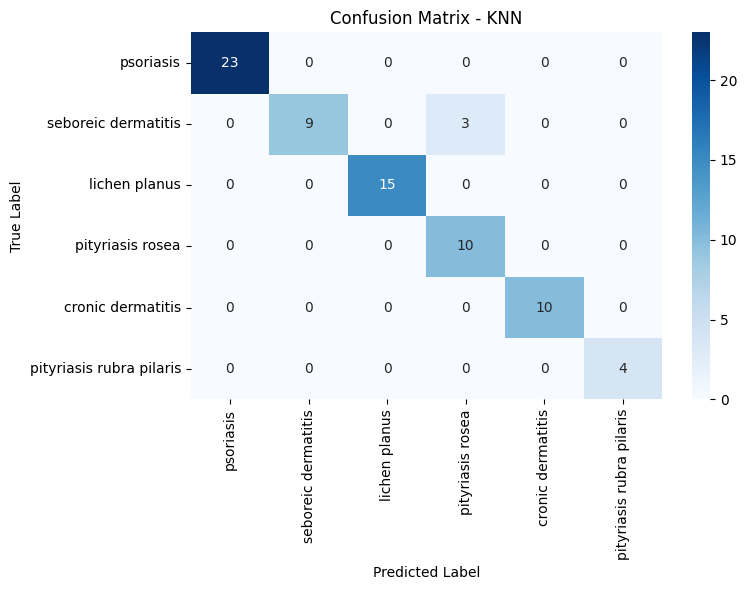

In [13]:
cm = confusion_matrix(y_test, y_preds)
 
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=actual_y_label,
    yticklabels=actual_y_label
)
 
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()